<a href="https://colab.research.google.com/github/JithmaKaluarachchi/RP-Project-Crash-Severity/blob/main/Severity_Type.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# SECTION 1 — MOUNT GOOGLE DRIVE & AUTO-SEARCH ZIP FILES

from google.colab import drive
import os

drive.mount('/content/drive')

SEARCH_DIR = "/content/drive/MyDrive"

us_zip = None
road_zip = None

# Auto-search for ZIP files in Drive
for root, dirs, files in os.walk(SEARCH_DIR):
    for f in files:
        name = f.lower()

        # Find US Accident ZIP
        if "accident" in name and name.endswith(".zip"):
            us_zip = os.path.join(root, f)

        # Find Road Sensor ZIP
        if ("road" in name or "sensor" in name) and name.endswith(".zip"):
            road_zip = os.path.join(root, f)

print("FOUND US ZIP:", us_zip)
print("FOUND ROAD ZIP:", road_zip)

if us_zip is None:
    raise FileNotFoundError("❌ US Accident ZIP not found. Upload it to Google Drive.")

if road_zip is None:
    raise FileNotFoundError("❌ Road Sensor ZIP not found. Upload it to Google Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FOUND US ZIP: /content/drive/MyDrive/Colab Notebooks/Research Project/Severity Type/US_Accidents_March23.csv.zip
FOUND ROAD ZIP: /content/drive/MyDrive/Colab Notebooks/Research Project/Severity Type/Road Data.zip


In [ ]:
# SECTION 2 — CREATE WORK FOLDERS + EXTRACT ZIP FILES

import zipfile

WORKDIR = "/content/work"
os.makedirs(WORKDIR, exist_ok=True)

US_EXTRACT = os.path.join(WORKDIR, "us_accidents")
ROAD_EXTRACT = os.path.join(WORKDIR, "road_data")

os.makedirs(US_EXTRACT, exist_ok=True)
os.makedirs(ROAD_EXTRACT, exist_ok=True)

# Extract US Accident dataset
if not os.listdir(US_EXTRACT):
    with zipfile.ZipFile(us_zip, 'r') as z:
        z.extractall(US_EXTRACT)

# Extract Road Sensor dataset
if not os.listdir(ROAD_EXTRACT):
    with zipfile.ZipFile(road_zip, 'r') as z:
        z.extractall(ROAD_EXTRACT)

print("US dataset contents:", os.listdir(US_EXTRACT))
print("Road dataset contents:", os.listdir(ROAD_EXTRACT))


US dataset contents: ['US_Accidents_March23.csv']
Road dataset contents: ['Road Data']


In [ ]:
# SECTION 3 — INSTALL LIBRARIES & IMPORTS

!pip install pyarrow fastparquet --quiet

import pandas as pd
import numpy as np
import os, glob, zipfile, warnings, gc, math, random
from collections import defaultdict
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")


In [ ]:
# SECTION 4 — LOAD US ACCIDENTS IN CHUNKS (RAM SAFE)

US_EXTRACT = "/content/work/us_accidents"

# Find CSV
us_csv = None
for f in os.listdir(US_EXTRACT):
    if f.endswith(".csv"):
        us_csv = os.path.join(US_EXTRACT, f)

print("Using US CSV:", us_csv)

chunksize = 50_000

usecols = [
    "ID","Severity","Start_Time","Weather_Condition",
    "Temperature(F)","Humidity(%)","Visibility(mi)",
    "Wind_Speed(mph)","Distance(mi)"
]

accum = {}

for chunk in pd.read_csv(us_csv, usecols=usecols, chunksize=chunksize, low_memory=True):

    # Convert Start Time
    chunk["Start_Time"] = pd.to_datetime(chunk["Start_Time"], errors="coerce")
    chunk = chunk.dropna(subset=["Severity", "Start_Time"])

    chunk["Hour"] = chunk["Start_Time"].dt.hour.astype(int)
    chunk["Weather"] = chunk["Weather_Condition"].fillna("Unknown")

    # Aggregate severity based on Weather + Hour
    for (w, h), group in chunk.groupby(["Weather", "Hour"]):
        key = (w, int(h))
        if key not in accum:
            accum[key] = {"sum":0, "count":0}
        accum[key]["sum"] += group["Severity"].sum()
        accum[key]["count"] += len(group)

print("Total Weather-Hour groups:", len(accum))


Using US CSV: /content/work/us_accidents/US_Accidents_March23.csv
Total Weather-Hour groups: 2097


In [ ]:
# SECTION 5 — CONVERT AGGREGATED SEVERITY TO DATAFRAME

weather_data = []

for (weather, hour), info in accum.items():
    avg_sev = info["sum"] / info["count"]
    weather_data.append([weather, hour, avg_sev, info["count"]])

weather_df = pd.DataFrame(weather_data,
                          columns=["Weather", "Hour", "Avg_Severity", "Sample_Count"])

weather_df.head()


,Weather,Hour,Avg_Severity,Sample_Count
0,Clear,0,2.635657,7718
1,Clear,1,2.648527,6009
2,Clear,2,2.651501,6264
3,Clear,3,2.685945,6069
4,Clear,4,2.458350,15126


In [ ]:
# SECTION 6 — LOAD ROAD SENSOR DATA

ROAD_EXTRACT = "/content/work/road_data"

sensor_csv = None

# Search inside all folders (recursive)
for root, dirs, files in os.walk(ROAD_EXTRACT):
    for f in files:
        low = f.lower()

        # Accept CSV or Excel file
        if low.endswith(".csv") or low.endswith(".xlsx") or low.endswith(".xls"):
            sensor_csv = os.path.join(root, f)
            break

    if sensor_csv:
        break

print("Detected sensor file:", sensor_csv)

# If nothing found → show error
if sensor_csv is None:
    raise FileNotFoundError(
        "❌ No CSV/XLSX/XLS sensor file found inside /content/work/road_data.\n"
        "➡️ Please upload your sensor dataset (CSV or Excel) into the ZIP."
    )

# Load file
if sensor_csv.endswith(".csv"):
    sensor_df = pd.read_csv(sensor_csv)
else:
    sensor_df = pd.read_excel(sensor_csv)

sensor_df.head()


Detected sensor file: /content/work/road_data/Road Data/Road Anomalies/10. Pothole/AccelerometerUncalibrated.csv


,time,seconds_elapsed,z,y,x
0,1696958164572493600,0.256494,12.134413,1.420360,0.124498
1,1696958164582516200,0.266516,7.310096,0.174777,0.259172
2,1696958164592539400,0.276539,12.757504,0.653617,0.905607
3,1696958164602562300,0.286562,7.338827,0.840365,-0.301669
4,1696958164612575500,0.296575,7.970896,1.286285,0.350152


In [ ]:
# SECTION 7 — CREATE ACCIDENT LABELS (ROBUST)

# Standard expected names
standard_cols = ["acc_x", "acc_y", "acc_z"]

# Check if these exist; if not, try common alternatives
for col in standard_cols:
    if col not in sensor_df.columns:
        # Try lowercase variants or 'x', 'y', 'z'
        alt = col[-1]  # 'x', 'y', 'z'
        if alt in sensor_df.columns:
            sensor_df = sensor_df.rename(columns={alt: col})
        else:
            raise ValueError(f"Missing required column: {col} or alternatives like '{alt}' in sensor data")

# Compute acceleration magnitude
sensor_df["acc_mag"] = np.sqrt(
    sensor_df["acc_x"]**2 + sensor_df["acc_y"]**2 + sensor_df["acc_z"]**2
)

# Define consistent accident threshold
ACCIDENT_THRESHOLD = 25
sensor_df["Accident"] = (sensor_df["acc_mag"] > ACCIDENT_THRESHOLD).astype(int)

sensor_df.head()



,time,seconds_elapsed,acc_z,acc_y,acc_x,acc_mag,Accident,Severity
0,1696958164572493600,0.256494,12.134413,1.420360,0.124498,12.217892,0,LOW
1,1696958164582516200,0.266516,7.310096,0.174777,0.259172,7.316777,0,LOW
2,1696958164592539400,0.276539,12.757504,0.653617,0.905607,12.806297,0,LOW
3,1696958164602562300,0.286562,7.338827,0.840365,-0.301669,7.392942,0,LOW
4,1696958164612575500,0.296575,7.970896,1.286285,0.350152,8.081604,0,LOW


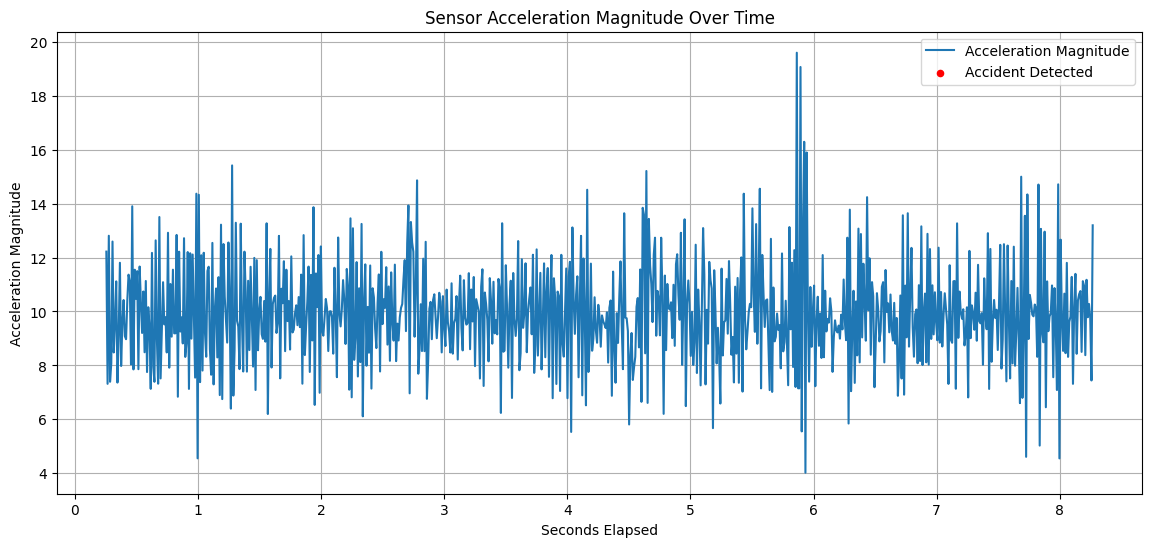

In [ ]:
# SECTION 8 — VISUALIZE SENSOR SIGNALS & ACCIDENT POINTS

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(sensor_df["seconds_elapsed"], sensor_df["acc_mag"], label="Acceleration Magnitude")

# Plot accident points
acc_points = sensor_df[sensor_df["Accident"] == 1]
plt.scatter(acc_points["seconds_elapsed"], acc_points["acc_mag"], s=20, color="red", label="Accident Detected")

plt.title("Sensor Acceleration Magnitude Over Time")
plt.xlabel("Seconds Elapsed")
plt.ylabel("Acceleration Magnitude")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# SECTION 9 — PREPARE DATASET FOR TRAINING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and labels
X = sensor_df[["acc_x", "acc_y", "acc_z", "acc_mag"]]
y = sensor_df["Accident"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (640, 4)
Testing samples: (161, 4)


In [ ]:
# SECTION 10 — TRAIN ACCIDENT DETECTION MODEL

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Model Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       161

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



In [ ]:
# SECTION 11 — SAVE MODEL & SCALER


import joblib

MODEL_PATH = "/content/accident_model.pkl"
SCALER_PATH = "/content/accident_scaler.pkl"

joblib.dump(model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print("Model saved to:", MODEL_PATH)
print("Scaler saved to:", SCALER_PATH)


Model saved to: /content/accident_model.pkl
Scaler saved to: /content/accident_scaler.pkl


In [ ]:
# SECTION 12 — REAL-TIME ACCIDENT DETECTION FUNCTION

def detect_accident_live(x, y, z):
    # Compute magnitude
    acc_mag = (x**2 + y**2 + z**2) ** 0.5

    # Prepare input
    sample = [[x, y, z, acc_mag]]

    # Scale using fitted scaler
    sample_scaled = scaler.transform(sample)

    # Predict
    pred = model.predict(sample_scaled)[0]

    return {
        "acc_x": x,
        "acc_y": y,
        "acc_z": z,
        "acc_mag": acc_mag,
        "Accident": int(pred)
    }

# Example test
detect_accident_live(8, 10, 20)


{'acc_x': 8,
 'acc_y': 10,
 'acc_z': 20,
 'acc_mag': 23.748684174075834,
 'Accident': 0}

In [ ]:
# SECTION 13 — ADD SEVERITY LEVELS

# Define consistent severity function
def severity_level(acc_mag):
    if acc_mag < 30:
        return "LOW"
    elif acc_mag < 50:
        return "MEDIUM"
    else:
        return "HIGH"

# Apply to entire sensor dataset
sensor_df["Severity"] = sensor_df["acc_mag"].apply(lambda x: severity_level(x) if x > ACCIDENT_THRESHOLD else "N/A")
sensor_df[["acc_mag", "Severity"]].head()



,acc_mag,Severity
0,12.217892,N/A
1,7.316777,N/A
2,12.806297,N/A
3,7.392942,N/A
4,8.081604,N/A


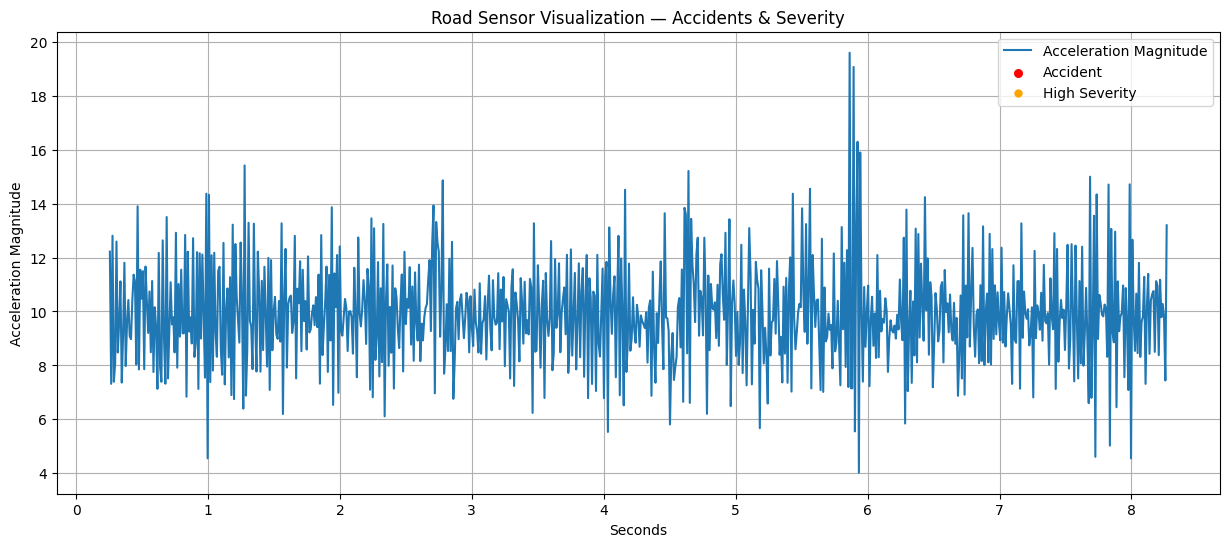

In [ ]:
# SECTION 14 — SENSOR DASHBOARD VISUALIZATION

plt.figure(figsize=(15, 6))

plt.plot(sensor_df["seconds_elapsed"], sensor_df["acc_mag"], label="Acceleration Magnitude")

# Plot accident points
acc = sensor_df[sensor_df["Accident"] == 1]
plt.scatter(acc["seconds_elapsed"], acc["acc_mag"], color="red", s=30, label="Accident")

# Plot high severity
high = sensor_df[sensor_df["Severity"] == "HIGH"]
plt.scatter(high["seconds_elapsed"], high["acc_mag"], color="orange", s=25, label="High Severity")

plt.title("Road Sensor Visualization — Accidents & Severity")
plt.xlabel("Seconds")
plt.ylabel("Acceleration Magnitude")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# SECTION 15 — SEVERITY CLASSIFICATION MODEL

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Features: accelerometer + magnitude
X_sev = sensor_df[["acc_x", "acc_y", "acc_z", "acc_mag"]]

# Labels: Severity (LOW / MEDIUM / HIGH)
y_sev = sensor_df["Severity"]

# Encode labels to numeric
le = LabelEncoder()
y_sev_encoded = le.fit_transform(y_sev)

# Train-test split
X_train_sev, X_test_sev, y_train_sev, y_test_sev = train_test_split(
    X_sev, y_sev_encoded, test_size=0.2, random_state=42, stratify=y_sev_encoded
)

# Normalize features (optional)
scaler_sev = StandardScaler()
X_train_sev_scaled = scaler_sev.fit_transform(X_train_sev)
X_test_sev_scaled = scaler_sev.transform(X_test_sev)

# Train RandomForest Classifier
sev_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
sev_model.fit(X_train_sev_scaled, y_train_sev)

# Predict
y_pred_sev = sev_model.predict(X_test_sev_scaled)

# Evaluation
print("Severity Model Accuracy:", accuracy_score(y_test_sev, y_pred_sev))
print("\nClassification Report:\n", classification_report(y_test_sev, y_pred_sev, target_names=le.classes_))

# Save Severity Model & Scaler
joblib.dump(sev_model, "/content/severity_model.pkl")
joblib.dump(scaler_sev, "/content/severity_scaler.pkl")
joblib.dump(le, "/content/severity_labelencoder.pkl")

print("Severity model, scaler, and label encoder saved successfully.")


Severity Model Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

         N/A       1.00      1.00      1.00       161

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161

Severity model, scaler, and label encoder saved successfully.


In [ ]:
# SECTION 16 — REAL-TIME ACCIDENT + SEVERITY PREDICTION

def predict_accident_severity(acc_x, acc_y, acc_z):
    """
    Input: acc_x, acc_y, acc_z (from sensor)
    Output: Accident status + Predicted severity
    """

    # Compute magnitude
    acc_mag = (acc_x**2 + acc_y**2 + acc_z**2) ** 0.5

    # Accident detection using consistent threshold
    accident_pred = acc_mag > ACCIDENT_THRESHOLD

    # Severity using consistent rules
    if accident_pred:
        severity_pred = severity_level(acc_mag)
    else:
        severity_pred = "N/A"

    return {
        "acc_x": acc_x,
        "acc_y": acc_y,
        "acc_z": acc_z,
        "acc_mag": acc_mag,
        "Accident": accident_pred,
        "Severity": severity_pred
    }

# Example test
example = predict_accident_severity(10, 5, 28)
print("Live Prediction:", example)


Live Prediction: {'acc_x': 10, 'acc_y': 5, 'acc_z': 28, 'acc_mag': 30.14962686336267, 'Accident': True, 'Severity': 'MEDIUM'}


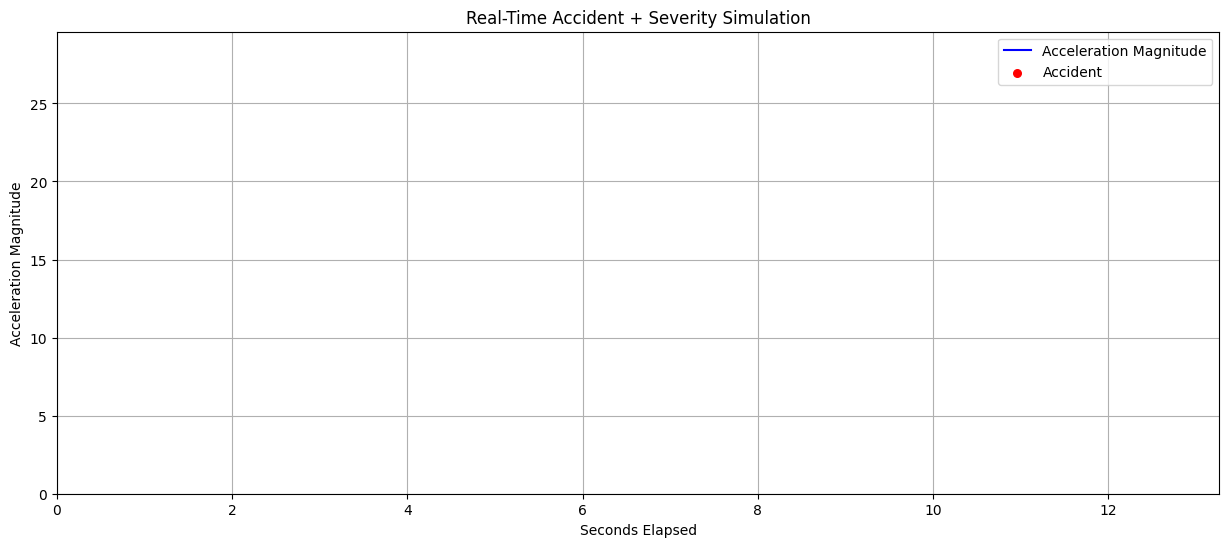

In [ ]:
# SECTION 17 — REAL-TIME SIMULATION PIPELINE (SMOOTH ANIMATION)

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Prepare figure
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlabel("Seconds Elapsed")
ax.set_ylabel("Acceleration Magnitude")
ax.set_title("Real-Time Accident + Severity Simulation")
ax.grid(True)

# Lines and scatter objects
line_acc, = ax.plot([], [], color="blue", label="Acceleration Magnitude")
scatter_acc = ax.scatter([], [], color="red", s=30, label="Accident")
text_annotations = []

# Data storage
x_vals, y_vals = [], []
acc_x_vals, acc_y_vals = [], []
acc_labels = []

# Initialize plot limits
ax.set_xlim(0, sensor_df["seconds_elapsed"].max() + 5)
ax.set_ylim(0, sensor_df["acc_mag"].max() + 10)
ax.legend()

# Update function for animation
def update(frame):
    global x_vals, y_vals, acc_x_vals, acc_y_vals, acc_labels, text_annotations

    row = sensor_df.iloc[frame]
    sec = row["seconds_elapsed"]
    x, y, z = row["acc_x"], row["acc_y"], row["acc_z"]

    result = predict_accident_severity(x, y, z)
    acc_mag = result["acc_mag"]

    # Store data
    x_vals.append(sec)
    y_vals.append(acc_mag)

    if result["Accident"]:
        acc_x_vals.append(sec)
        acc_y_vals.append(acc_mag)
        acc_labels.append(result["Severity"])

    # Update line
    line_acc.set_data(x_vals, y_vals)

    # Update scatter
    scatter_acc.set_offsets(list(zip(acc_x_vals, acc_y_vals)))

    # Remove old text annotations
    for txt in text_annotations:
        txt.remove()
    text_annotations.clear()

    # Add new text annotations for accidents
    for i, label in enumerate(acc_labels):
        txt = ax.text(acc_x_vals[i], acc_y_vals[i] + 1, label, fontsize=8, color="black")
        text_annotations.append(txt)

    return line_acc, scatter_acc, *text_annotations

# Create animation
ani = FuncAnimation(
    fig, update, frames=len(sensor_df), interval=20, blit=False, repeat=False
)

plt.show()


In [ ]:
# SECTION 18 — MODEL ACCURACY REPORT

from sklearn.metrics import accuracy_score

# Accident Detection Model
y_train_pred_acc = model.predict(X_train)
y_test_pred_acc = model.predict(X_test)

train_acc_accident = accuracy_score(y_train, y_train_pred_acc)
test_acc_accident = accuracy_score(y_test, y_test_pred_acc)

print("=== Accident Detection Model Accuracy ===")
print(f"Training Accuracy: {train_acc_accident*100:.2f}%")
print(f"Testing Accuracy:  {test_acc_accident*100:.2f}%\n")


# Severity Classification Model
y_train_pred_sev = sev_model.predict(X_train_sev_scaled)
y_test_pred_sev = sev_model.predict(X_test_sev_scaled)

train_acc_severity = accuracy_score(y_train_sev, y_train_pred_sev)
test_acc_severity = accuracy_score(y_test_sev, y_test_pred_sev)

print("=== Severity Classification Model Accuracy ===")
print(f"Training Accuracy: {train_acc_severity*100:.2f}%")
print(f"Testing Accuracy:  {test_acc_severity*100:.2f}%")


=== Accident Detection Model Accuracy ===
Training Accuracy: 100.00%
Testing Accuracy:  100.00%

=== Severity Classification Model Accuracy ===
Training Accuracy: 100.00%
Testing Accuracy:  100.00%


In [ ]:
# SECTION 19 — TEST COMBINED MODEL WITH ADJUSTED SEVERITY

def test_threshold_combined_model(acc_x, acc_y, acc_z, threshold=20):
    """
    Inputs: acc_x, acc_y, acc_z from sensor
    Outputs: Accident status + Severity (LOW/MEDIUM/HIGH/N/A)
    """
    # Compute acceleration magnitude
    acc_mag = (acc_x**2 + acc_y**2 + acc_z**2) ** 0.5

    # Accident detection using threshold
    accident_pred = acc_mag > threshold

    # Severity prediction using adjusted rules
    if accident_pred:
        if acc_mag <= 30:
            severity_pred = "LOW"
        elif acc_mag <= 50:
            severity_pred = "MEDIUM"
        else:
            severity_pred = "HIGH"
    else:
        severity_pred = "N/A"

    return {
        "acc_x": acc_x,
        "acc_y": acc_y,
        "acc_z": acc_z,
        "acc_mag": acc_mag,
        "Accident": accident_pred,
        "Severity": severity_pred
    }

# Test samples
test_samples = [
    (0.1, 0.2, 0.1),
    (5, 4, 3),
    (12, 10, 8),
    (15, 12, 10),
    (18, 20, 15),
    (25, 30, 20),
    (30, 35, 25),
    (50, 50, 50),
]

for sample in test_samples:
    result = predict_accident_severity(*sample)
    print(result)


{'acc_x': 0.1, 'acc_y': 0.2, 'acc_z': 0.1, 'acc_mag': 0.24494897427831783, 'Accident': False, 'Severity': 'N/A'}
{'acc_x': 5, 'acc_y': 4, 'acc_z': 3, 'acc_mag': 7.0710678118654755, 'Accident': False, 'Severity': 'N/A'}
{'acc_x': 12, 'acc_y': 10, 'acc_z': 8, 'acc_mag': 17.549928774784245, 'Accident': False, 'Severity': 'N/A'}
{'acc_x': 15, 'acc_y': 12, 'acc_z': 10, 'acc_mag': 21.656407827707714, 'Accident': False, 'Severity': 'N/A'}
{'acc_x': 18, 'acc_y': 20, 'acc_z': 15, 'acc_mag': 30.805843601498726, 'Accident': True, 'Severity': 'MEDIUM'}
{'acc_x': 25, 'acc_y': 30, 'acc_z': 20, 'acc_mag': 43.87482193696061, 'Accident': True, 'Severity': 'MEDIUM'}
{'acc_x': 30, 'acc_y': 35, 'acc_z': 25, 'acc_mag': 52.44044240850758, 'Accident': True, 'Severity': 'HIGH'}
{'acc_x': 50, 'acc_y': 50, 'acc_z': 50, 'acc_mag': 86.60254037844386, 'Accident': True, 'Severity': 'HIGH'}
